In [1]:
"""
    Code to plot figures simulated and randomly permuted data
    Supplemental Figure S16
"""

import os
import numpy as np

save_path = 'results/sim/data/'

zero_pval_0, zero_pval_1, zero_pval_01, parent_pval_01 = [], [], [], []
for i in [0,1,3]:
    files = sorted(
        f for f in os.listdir(save_path)
        if f.startswith(f"sim_results_y{i}") and f.endswith(".npy")
    )
    
    data = [np.load(os.path.join(save_path, f), allow_pickle=True).item() for f in files]
    
    zero_pval_0.append(np.array([d["zero_pval"][0, 0] for d in data]))
    zero_pval_1.append(np.array([d["zero_pval"][1, 1] for d in data]))
    zero_pval_01.append(np.array([d["zero_pval"][0, 1] for d in data]))
    parent_pval_01.append(np.array([d["parent_pval"][0, 1] for d in data]))

[16.0, 22.0, 53.0] [5.0, 8.0, 28.999999999999996] [2.0, 3.0, 7.000000000000001]
[12.0, 27.0, 44.0] [2.0, 8.0, 21.0] [2.0, 1.0, 2.0]
[100.0, 100.0, 100.0] [100.0, 100.0, 100.0] [100.0, 100.0, 100.0]


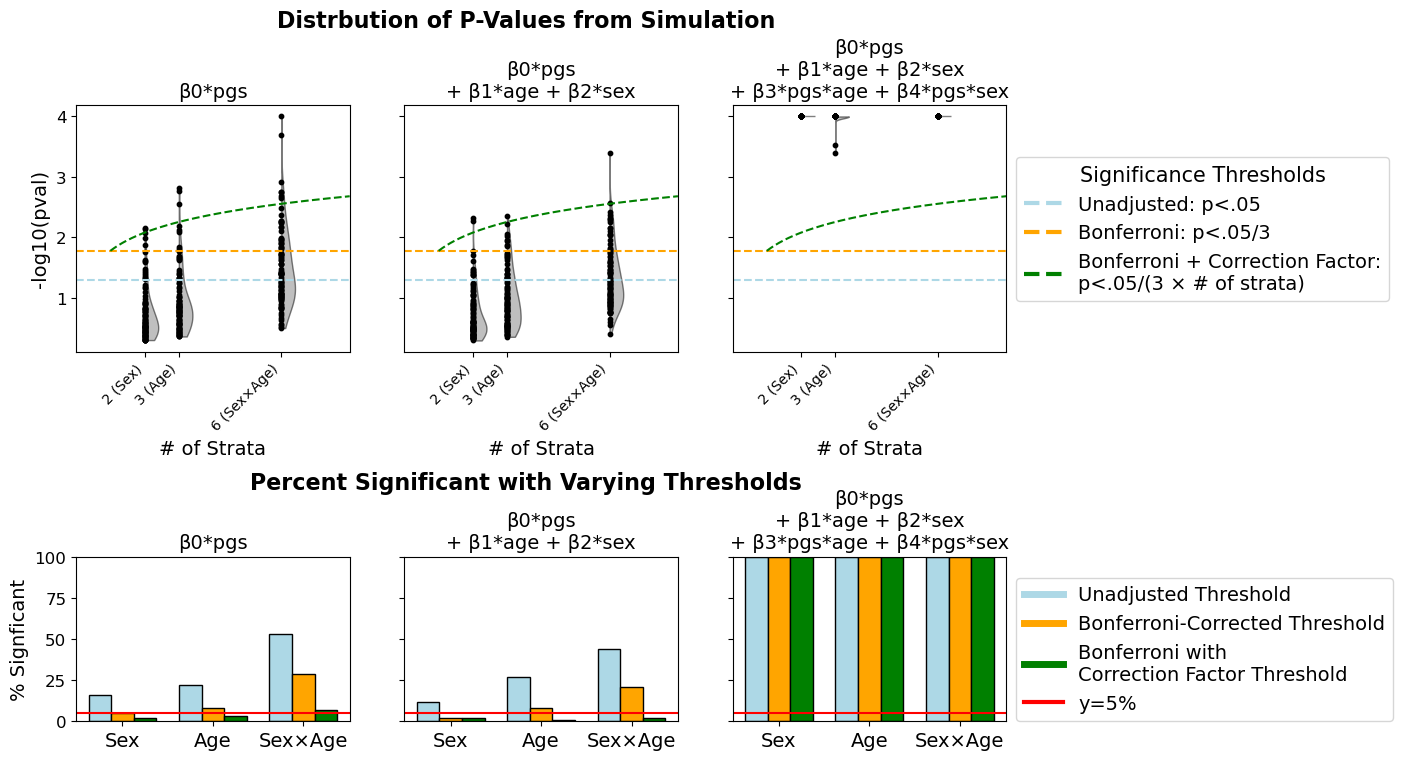

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import math

fig, axes = plt.subplots(
    2, 3, figsize=(12, 8), sharey='row',
    gridspec_kw={'height_ratios': [1.5, 1]}
)

alpha1 = 0.05
alpha2 = 0.05/3

title = ['β0*pgs', 'β0*pgs\n+ β1*age + β2*sex', 
         'β0*pgs\n+ β1*age + β2*sex\n+ β3*pgs*age + β4*pgs*sex', 
         'β0*pgs\n+ β1*age + β2*sex\n+ β3*pgs*age + β4*pgs*sex']

for i in range(3):
    ax = axes[0, i]
    parts = ax.violinplot(
        [-np.log10(zero_pval_0[i]), -np.log10(zero_pval_1[i]), -np.log10(zero_pval_01[i])],
        positions=[2, 3, 6],
        widths=0.8,
        showmeans=False,
        showmedians=False,
        showextrema=False
    )
    for pc in parts['bodies']:
        m = np.mean(pc.get_paths()[0].vertices[:, 0])
        pc.set_clip_path(None)
        pc.set_alpha(0.5)
        pc.set_facecolor('gray')
        pc.set_edgecolor('black')
        pc.set_linewidth(1)
        pc.get_paths()[0].vertices[:, 0] = np.clip(pc.get_paths()[0].vertices[:, 0], m, np.inf)
    ax.scatter(np.full(zero_pval_0[i].shape, 2.0), -np.log10(zero_pval_0[i]), s=10, color='black')
    ax.scatter(np.full(zero_pval_1[i].shape, 3.0), -np.log10(zero_pval_1[i]), s=10, color='black')
    ax.scatter(np.full(zero_pval_01[i].shape, 6.0), -np.log10(zero_pval_01[i]), s=10, color='black')
    ax.hlines(-np.log10(alpha1), 0, 8, linestyle='--', color='lightblue')
    ax.hlines(-np.log10(alpha2), 0, 8, linestyle='--', color='orange')
    x_vals = np.linspace(1, 8, 200)
    ax.plot(x_vals, -np.log10(0.05/(3*x_vals)), linestyle='--', color='green')
    ax.set_xlim(0, 8)
    ax.set_xticks([2, 3, 6])
    ax.set_xticklabels(['2 (Sex)', '3 (Age)', '6 (Sex×Age)'], rotation=45, ha='right')
    ax.set_xlabel('# of Strata', fontsize=14)
    if i == 0:
        ax.set_ylabel('-log10(pval)', fontsize=14)
    ax.set_title(title[i], fontsize=14)

for i in range(3):
    axb = axes[1, i]
    groups = ['Sex', 'Age', 'Sex×Age']
    vals = [zero_pval_0[i], zero_pval_1[i], zero_pval_01[i]]
    pct_a1 = [np.mean(v < alpha1) * 100 for v in vals]
    pct_a2 = [np.mean(v < alpha2) * 100 for v in vals]
    pct_a3 = [np.mean(v < (0.05/(3*g))) * 100 for v, g in zip(vals, [2, 3, 6])]
    print(pct_a1, pct_a2, pct_a3)
    x = np.arange(len(groups))
    w = 0.25
    axb.bar(x - w, pct_a1, width=w, color='lightblue', edgecolor='black')
    axb.bar(x, pct_a2, width=w, color='orange', edgecolor='black')
    axb.bar(x + w, pct_a3, width=w, color='green', edgecolor='black')
    axb.set_xticks(x)
    axb.set_xticklabels(groups, fontsize=14)
    axb.set_ylim(0, 100)
    axb.set_title(title[i], fontsize=14)
    axb.set_ylabel("", fontsize=14)
    if i == 0:
        axb.set_ylabel("% Signficant", fontsize=14)
    
    axb.axhline(5, linestyle='-', color='red')

for ax in axes[0]:
    ax.tick_params(axis='y', labelsize=12)
for ax in axes[1]:
    ax.tick_params(axis='y', labelsize=12)

fig.suptitle('Distrbution of P-Values from Simulation', fontsize=16, y=1, fontweight='bold')
fig.text(0.5, 0.4, 'Percent Significant with Varying Thresholds', fontsize=16, ha='center', fontweight='bold')

#fig.subplots_adjust(top=0.88, bottom=0.08, right=0.82, hspace=3.0, wspace=0.5)
fig.subplots_adjust(hspace=1)

handles = [
    Line2D([0], [0], linestyle='--', color='lightblue', linewidth=3),
    Line2D([0], [0], linestyle='--', color='orange', linewidth=3),
    Line2D([0], [0], linestyle='--', color='green', linewidth=3)
]
labels = [
    'Unadjusted: p<.05',
    'Bonferroni: p<.05/3',
    'Bonferroni + Correction Factor:\np<.05/(3 × # of strata)'
]
fig.legend(handles, labels, title='Significance Thresholds', title_fontsize=15,
           loc='center left', bbox_to_anchor=(0.9, 0.725), fontsize=14)

handles = [
    Line2D([0], [0], linestyle='-', color='lightblue', linewidth=5),
    Line2D([0], [0], linestyle='-', color='orange', linewidth=5),
    Line2D([0], [0], linestyle='-', color='green', linewidth=5),
    Line2D([0], [0], linestyle='-', color='red', linewidth=3)
]
labels = [
    'Unadjusted Threshold',
    'Bonferroni-Corrected Threshold',
    'Bonferroni with\nCorrection Factor Threshold',
    'y=5%'
]
fig.legend(handles, labels, title_fontsize=15,
           loc='center left', bbox_to_anchor=(0.9, 0.2), fontsize=14)

#plt.tight_layout(rect=[0, 0, 0.82, 0.92])
file_nm = f'results/sim/sim_results.png'
plt.savefig(file_nm, bbox_inches='tight')

[3.0, 4.0, 92.92929292929293]


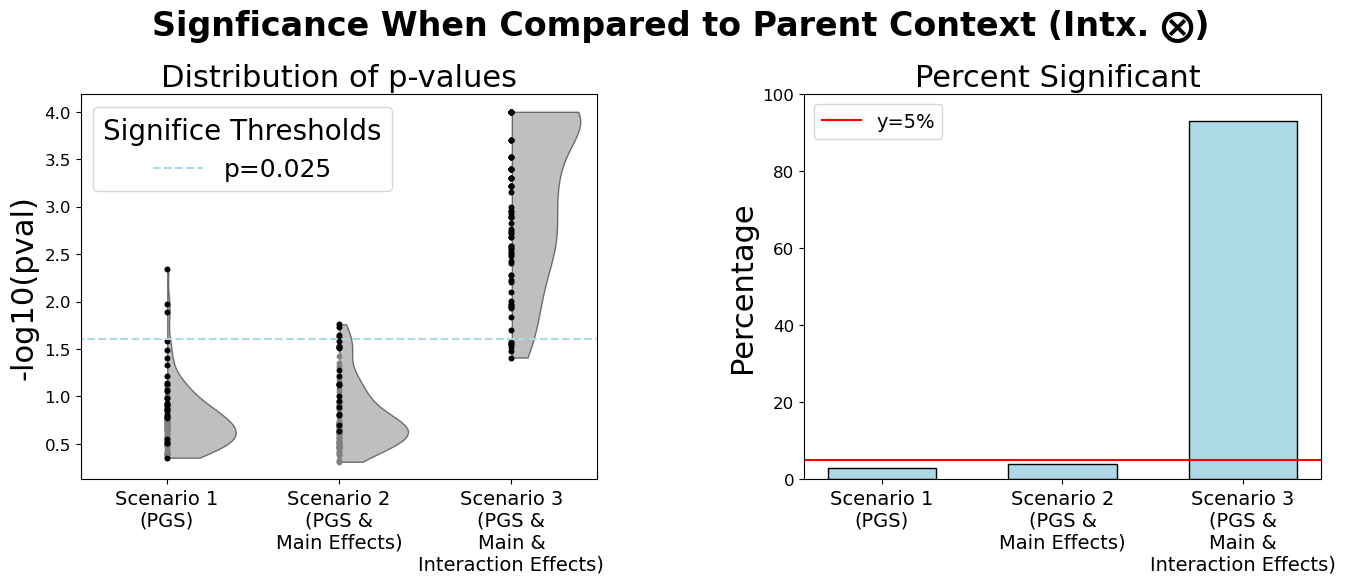

In [12]:
alpha = 0.025

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax = axes[0]
parts = ax.violinplot(
    [-np.log10(parent_pval_01[0]), -np.log10(parent_pval_01[1]), -np.log10(parent_pval_01[2])],
    positions=[1, 2, 3],
    widths=0.8,
    showmeans=False,
    showmedians=False,
    showextrema=False
)
for pc in parts['bodies']:
    m = np.mean(pc.get_paths()[0].vertices[:, 0])
    pc.set_clip_path(None)
    pc.set_alpha(0.5)
    pc.set_facecolor('gray')
    pc.set_edgecolor('black')
    pc.set_linewidth(1)
    pc.get_paths()[0].vertices[:, 0] = np.clip(pc.get_paths()[0].vertices[:, 0], m, np.inf)

zero_vals = [zero_pval_01[0]<.05/3, zero_pval_01[1]<.05/3, zero_pval_01[2]<.05/3]
ax.scatter(np.full(parent_pval_01[0].shape, 1.0), -np.log10(parent_pval_01[0]), s=10, color='gray')
ax.scatter(np.full(parent_pval_01[1].shape, 2.0), -np.log10(parent_pval_01[1]), s=10, color='gray')
ax.scatter(np.full(parent_pval_01[2].shape, 3.0), -np.log10(parent_pval_01[2]), s=10, color='gray')

ax.scatter(np.full(parent_pval_01[0][zero_vals[0]].shape, 1.0), -np.log10(parent_pval_01[0][zero_vals[0]]), s=10, color='black')
ax.scatter(np.full(parent_pval_01[1][zero_vals[1]].shape, 2.0), -np.log10(parent_pval_01[1][zero_vals[1]]), s=10, color='black')
ax.scatter(np.full(parent_pval_01[2][zero_vals[2]].shape, 3.0), -np.log10(parent_pval_01[2][zero_vals[2]]), s=10, color='black')

ax.hlines(-np.log10(alpha), 0, 4, linestyle='--', color='lightblue', label=f'p={alpha}')
ax.set_xlim(0.5, 3.5)
ax.set_xticks([1, 2, 3])
ax.set_xticklabels(['Scenario 1\n(PGS)', 'Scenario 2\n(PGS &\nMain Effects)', 'Scenario 3\n(PGS &\nMain &\nInteraction Effects)'], fontsize=14)
ax.set_ylabel('-log10(pval)', fontsize=22)
ax.set_title('Distribution of p-values', fontsize=22)
ax.legend(title="Significe Thresholds", title_fontsize=20, fontsize=18, loc='upper left')

axb = axes[1]
groups = ['Scenario 1\n(PGS)', 'Scenario 2\n(PGS &\nMain Effects)', 'Scenario 3\n(PGS &\nMain &\nInteraction Effects)']
vals = [(parent_pval_01[0]< alpha)*zero_vals[0], (parent_pval_01[1]<alpha)*zero_vals[1], (parent_pval_01[2]< alpha)*zero_vals[2]]
pct = [np.mean(v) * 100 for v in vals]
print(pct)
x = np.arange(len(groups))
w = 0.6

bars = axb.bar(x, pct, width=w, color='lightblue', edgecolor='black')
axb.set_xticks(x)
axb.set_xticklabels(groups, fontsize=14)
axb.set_ylim(0, 100)
axb.set_ylabel('Percentage', fontsize=22)
axb.set_title('Percent Significant ', fontsize=22)
axb.axhline(5, linestyle='-', color='red', label='y=5%')
axb.legend(fontsize=14, loc='upper left')

for ax in axes:
    ax.tick_params(axis='y', labelsize=12)

fig.suptitle('Signficance When Compared to Parent Context (Intx. ⨂)', fontsize=24, y=1.05, fontweight='bold')
fig.subplots_adjust(wspace=0.4)

file_nm = f'results/sim/sim_results_p2.png'
plt.savefig(file_nm, bbox_inches='tight')

In [44]:
from options.options import Options

phen_label = 'MDD'

opt = Options()
opt.initialize()

base_dir = f"results/rand_{phen_label}"
pval_zero = []
pval_parent = []
for folder in os.listdir(base_dir):
    folder_path = os.path.join(base_dir, folder)
    if os.path.isdir(folder_path):
        file_path_zero = os.path.join(folder_path, "pval_zero.npy")
        file_path_parent = os.path.join(folder_path, "pval_parent.npy")
        if os.path.isfile(file_path_zero):
            try:
                data = np.load(file_path_zero)
                pval_zero.append(data)
                
                data = np.load(file_path_parent)
                pval_parent.append(data)
            except:
                pass

pval_zero = np.array(pval_zero)
pval_parent = np.array(pval_parent)
pval_zero_mean = (pval_zero<.05).mean(0)*100
pval_parent_mean = (pval_parent<.05).mean(0)*100

print(pval_zero.shape[0])

100


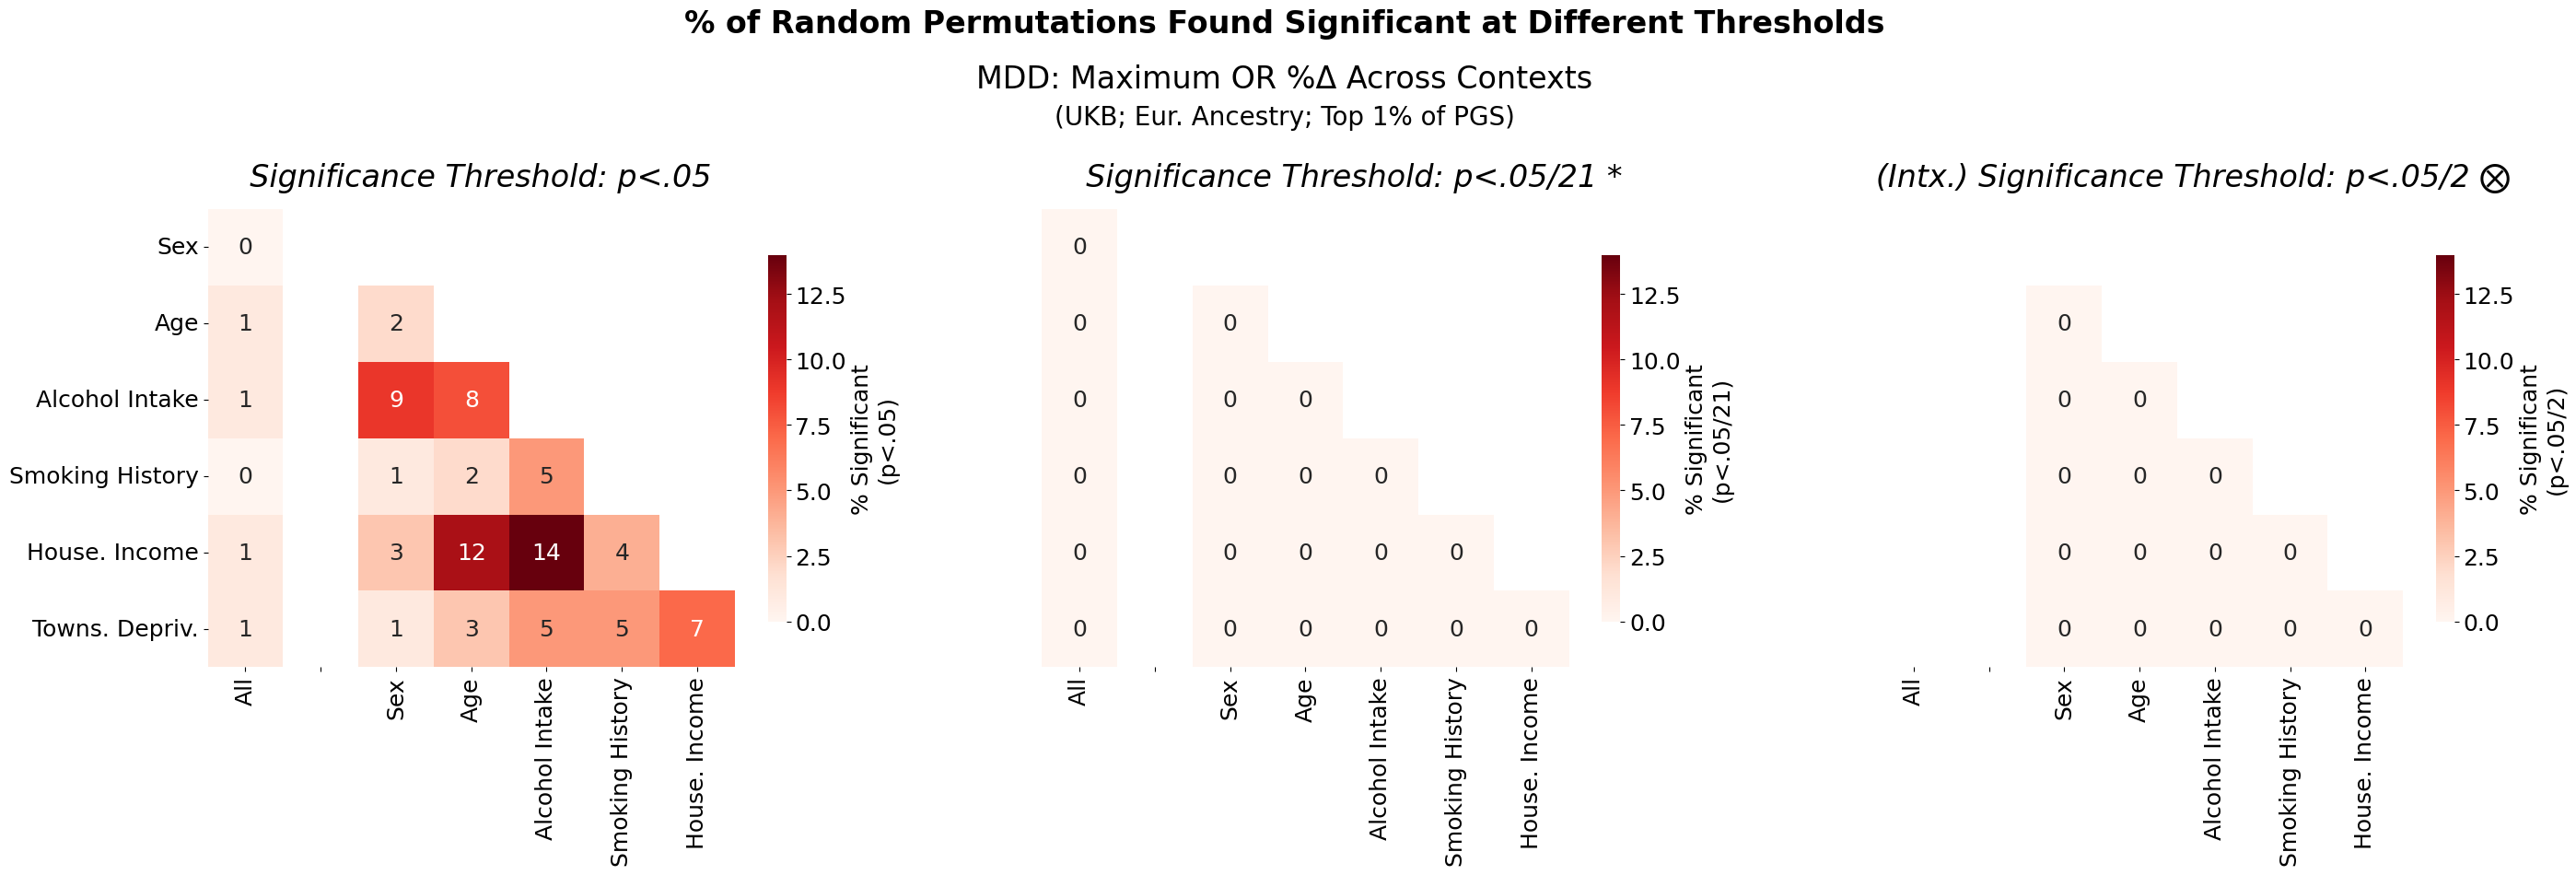

In [45]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

phen_title = opt.phen_params[phen_label]['title']
emerge_cutoff = opt.phen_params[phen_label]['emerge_cut']

def format_for_heatmap(mat):
    heatmap = mat
    diagonal = np.diag(heatmap)
    lower_triangle_mask = np.triu(np.ones_like(mat, dtype=bool), k=0)
    heatmap = np.where(lower_triangle_mask, np.nan, heatmap)
    blank_columns = np.full((heatmap.shape[0], 2), np.nan)
    heatmap = np.hstack((blank_columns, heatmap))
    heatmap[:, 0] = diagonal
    return heatmap

xlabels = ['All', '', 'Sex', 'Age', 'Alcohol Intake', 'Smoking History', 'House. Income', 'Towns. Depriv.']

thresholds = [0.05, 0.05/21, 0.025]

titles = [
    '  Significance Threshold: p<.05',
    '          Significance Threshold: p<.05/21 *',
    '           (Intx.) Significance Threshold: p<.05/2 ⨂'
]
cbar_labels = [
    '% Significant\n(p<.05)',
    '% Significant\n(p<.05/21)',
    '% Significant\n(p<.05/2)'
]

pval_sources = [pval_zero, pval_zero, pval_parent]

heatmaps = []
for src, thr in zip(pval_sources, thresholds):
    mean_mat = (src < thr).mean(0) * 100
    heatmaps.append(format_for_heatmap(mean_mat))
heatmaps[2][:,0] = np.nan
heatmaps[2] = heatmaps[2]*heatmaps[1]

vmin = np.nanmin([np.nanmin(h[:, :-1]) for h in heatmaps])
vmax = np.nanmax([np.nanmax(h[:, :-1]) for h in heatmaps])

fig, axes = plt.subplots(1, 3, figsize=(28, 8))

for i, (ax, hmap, title, cbar_label) in enumerate(zip(axes, heatmaps, titles, cbar_labels)):
    hm = sns.heatmap(
        hmap[:, :-1],
        cmap="Reds",
        annot=True,
        fmt=".0f",
        cbar=True,
        xticklabels=xlabels[:-1],
        yticklabels=xlabels[2:] if i == 0 else [],
        mask=np.isnan(hmap[:, :-1]),
        cbar_kws={'shrink': 0.8, 'label': cbar_label},
        annot_kws={"size": 18},
        vmin=vmin,
        vmax=vmax,
        ax=ax
    )
    ax.text(
        0.5, 1.05,
        title,
        fontsize=24,
        fontstyle='italic',
        ha='center',
        transform=ax.transAxes
    )
    ax.tick_params(axis='x', labelsize=18)
    ax.tick_params(axis='y', labelsize=18)
    cbar = hm.collections[0].colorbar
    cbar.ax.yaxis.label.set_size(18)
    cbar.ax.tick_params(labelsize=18)

fig.text(
    0.5, 1.15,
    f'% of Random Permutations Found Significant at Different Thresholds',
    fontsize=24,
    fontweight='bold',
    ha='center',
    transform=fig.transFigure
)
fig.text(
    0.5, 1.075,
    f'{phen_title}: Maximum OR %Δ Across Contexts',
    fontsize=24,
    ha='center',
    transform=fig.transFigure
)
fig.text(
    0.5, 1.025,
    f'(UKB; Eur. Ancestry; Top {int(100*emerge_cutoff)}% of PGS)',
    fontsize=20,
    ha='center',
    transform=fig.transFigure
)

plt.tight_layout()

file_nm = f'results/sim/rand_{phen_label}_results.png'
plt.savefig(file_nm, bbox_inches='tight')